Please upload housing.csv


Saving housing.csv to housing.csv

========== First 5 Rows ==========
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

====

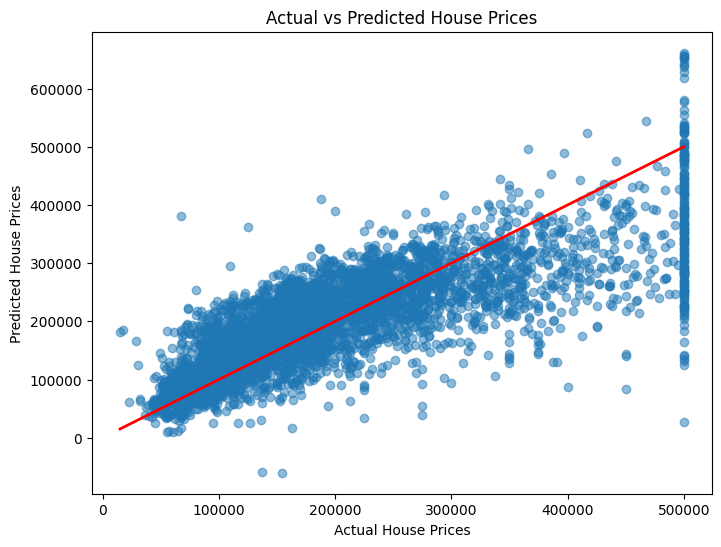

<Figure size 1000x600 with 0 Axes>

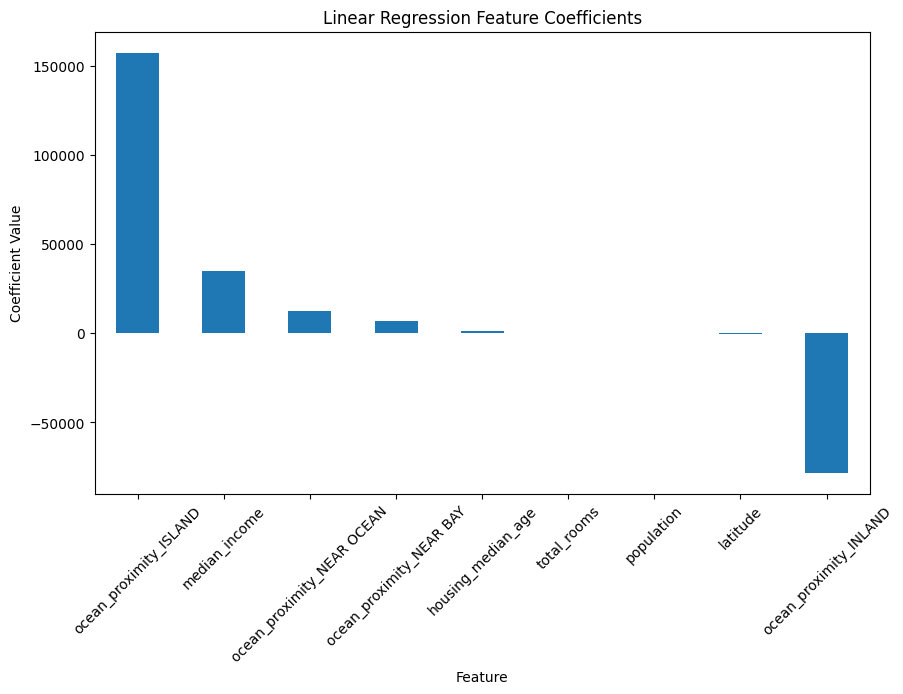


========== R² Score Explanation ==========

The model achieved an R² score of 0.60.

This means the model explains about 59.6% of the variation in house prices
using the selected features.

A higher R² score means the model's predictions are closer to the real house prices.
The RMSE shows the average prediction error, where a lower value indicates better performance.


========== Conclusion ==========

✔ Dataset loaded successfully.
✔ Missing values handled.
✔ Categorical data encoded.
✔ Linear Regression model trained.
✔ RMSE calculated.
✔ R² Score calculated.
✔ Actual vs Predicted scatter plot generated.

Task 3 completed successfully.



In [1]:
# ==========================================================
# House Price Prediction using Linear Regression
# Author: Faizan Khan
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ----------------------------------------------------------
# Upload Dataset
# ----------------------------------------------------------
print("Please upload housing.csv")
uploaded = files.upload()

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------
df = pd.read_csv("housing.csv")

print("\n========== First 5 Rows ==========")
print(df.head())

print("\n========== Dataset Information ==========")
print(df.info())

print("\n========== Missing Values ==========")
print(df.isnull().sum())

print("\n========== Dataset Shape ==========")
print(df.shape)

# ----------------------------------------------------------
# Handle Missing Values
# ----------------------------------------------------------
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

# ----------------------------------------------------------
# One-Hot Encode Categorical Column
# ----------------------------------------------------------
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

# ----------------------------------------------------------
# Select Features
# ----------------------------------------------------------
selected_features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population",
    "latitude"
]

# Add encoded ocean proximity columns
encoded_columns = [col for col in df.columns if col.startswith("ocean_proximity_")]
selected_features.extend(encoded_columns)

X = df[selected_features]
y = df["median_house_value"]

# ----------------------------------------------------------
# Train-Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))

# ----------------------------------------------------------
# Train Linear Regression Model
# ----------------------------------------------------------
model = LinearRegression()

model.fit(X_train, y_train)

print("\n✅ Model Trained Successfully!")

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------
y_pred = model.predict(X_test)

# ----------------------------------------------------------
# Model Evaluation
# ----------------------------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n========== Model Performance ==========")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

# ----------------------------------------------------------
# Feature Coefficients
# ----------------------------------------------------------
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\n========== Feature Coefficients ==========")
print(coefficients)

# ----------------------------------------------------------
# Actual vs Predicted Scatter Plot
# ----------------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

# ----------------------------------------------------------
# Feature Importance Plot
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

coefficients.plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    legend=False,
    figsize=(10,6)
)

plt.title("Linear Regression Feature Coefficients")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)

plt.show()

# ----------------------------------------------------------
# Plain English Explanation
# ----------------------------------------------------------
print("\n========== R² Score Explanation ==========")
print(f"""
The model achieved an R² score of {r2:.2f}.

This means the model explains about {r2*100:.1f}% of the variation in house prices
using the selected features.

A higher R² score means the model's predictions are closer to the real house prices.
The RMSE shows the average prediction error, where a lower value indicates better performance.
""")

# ----------------------------------------------------------
# Final Conclusion
# ----------------------------------------------------------
print("\n========== Conclusion ==========")
print("""
✔ Dataset loaded successfully.
✔ Missing values handled.
✔ Categorical data encoded.
✔ Linear Regression model trained.
✔ RMSE calculated.
✔ R² Score calculated.
✔ Actual vs Predicted scatter plot generated.

Task 3 completed successfully.
""")